## RQ2: Rescorla Wagner Comparison Across Gemini, Deepseek and Human Data

### Data Imports and Checks

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# For Human data, take only the sessions with 100 trials to ensure fair comparison
# across variants and between humans and agents
human = pd.read_csv("../data/iowa_human/human_rw_results.csv")
human = human[(human['experiment'] == 1)]

In [3]:
gemini = pd.read_csv("../data/iowa_models/gemini/gemini_rw_results.csv")
deepseek = pd.read_csv("../data/iowa_models/deepseek/deepseek_rw_results.csv")

In [4]:
# keep only comparable columns
gemini = gemini[["session_id","variant","n_trials","alpha","beta","nll","converged"]]
deepseek = deepseek[["session_id","variant","n_trials","alpha","beta","nll","converged"]]
human = human[["session_id","variant","n_trials","alpha","beta","nll","converged"]]

# label datasets
gemini["dataset"] = "Gemini"
deepseek["dataset"] = "DeepSeek"
human["dataset"] = "Human"

# combine
df = pd.concat([gemini, deepseek, human], ignore_index=True)

print(df.head())

   session_id  variant  n_trials     alpha        beta        nll  converged  \
0           1        1       100  0.026964   29.136800  11.535960       True   
1           2        1       100  0.004168  100.000000  14.836925       True   
2           3        1       100  0.389820    1.669880  68.954671       True   
3           4        1       100  0.035142   24.497320  13.881012       True   
4           5        1       100  0.016720   17.052809  42.928515       True   

  dataset  
0  Gemini  
1  Gemini  
2  Gemini  
3  Gemini  
4  Gemini  


In [5]:
df.head()

,session_id,variant,n_trials,alpha,beta,nll,converged,dataset
0,1,1,100,0.026964,29.136800,11.535960,True,Gemini
1,2,1,100,0.004168,100.000000,14.836925,True,Gemini
2,3,1,100,0.389820,1.669880,68.954671,True,Gemini
3,4,1,100,0.035142,24.497320,13.881012,True,Gemini
4,5,1,100,0.016720,17.052809,42.928515,True,Gemini


In [6]:
print(df["dataset"].value_counts())

dataset
Gemini      450
DeepSeek    450
Human       410
Name: count, dtype: int64


In [7]:
print(df.groupby(["dataset","variant"]).size())

dataset   variant
DeepSeek  1          200
          2          200
          3           50
Gemini    1          200
          2          200
          3           50
Human     1          159
          2          222
          3           29
dtype: int64


## Summary Statistic Tables

### Variant Values

- Variant 1: Playing 100 trials, goal is to maximise profit

- Variant 2: Play until told to stop, goal is to maximise profit

- Variant 3: Play until told to stop, goal is to try to finish with at least 2500$

In [8]:
summary = df.groupby("dataset")[["alpha", "beta", "nll"]].agg(["mean", "median", "std"])
summary

alpha                           beta                       \
              mean    median       std       mean    median        std   
dataset                                                                  
DeepSeek  0.097331  0.007174  0.196233  27.011253  3.787659  40.792374   
Gemini    0.274267  0.084384  0.325971  19.939100  8.692141  30.597260   
Human     0.160917  0.000490  0.327965  20.341255  0.150605  37.989310   

                 nll                         
                mean      median        std  
dataset                                      
DeepSeek  108.431751  118.444846  29.280160  
Gemini     33.622382   27.807813  20.612299  
Human     128.396070  136.885605  18.242650

In [9]:
variant_summary = df.groupby(["dataset", "variant"])[["alpha", "beta", "nll"]].agg(["mean", "median"])
variant_summary

alpha                 beta                    nll  \
                      mean    median       mean     median        mean   
dataset  variant                                                         
DeepSeek 1        0.126431  0.011273  23.316313   0.946964  109.906416   
         2        0.080660  0.005020  32.533904   4.616090  108.220132   
         3        0.047616  0.004880  19.700406   4.075495  103.379568   
Gemini   1        0.243164  0.077632  23.235032  10.268907   33.440232   
         2        0.275877  0.086597  18.557920   8.111896   33.277632   
         3        0.392239  0.151576  12.280098   5.877323   35.729984   
Human    1        0.212147  0.001005  17.420310   0.141158  128.683395   
         2        0.134594  0.000355  23.235746   0.165940  127.755081   
         3        0.081540  0.000100  14.198267   0.000100  131.727621   

                              
                      median  
dataset  variant              
DeepSeek 1        122.881185  
         2        115.366301  
         3        108.371969  
Gemini   1         27.742623  
         2         26.636033  
         3         31.066875  
Human    1        135.846415  
         2        136.760570  
         3        138.629436

## Learning Rate Across Models

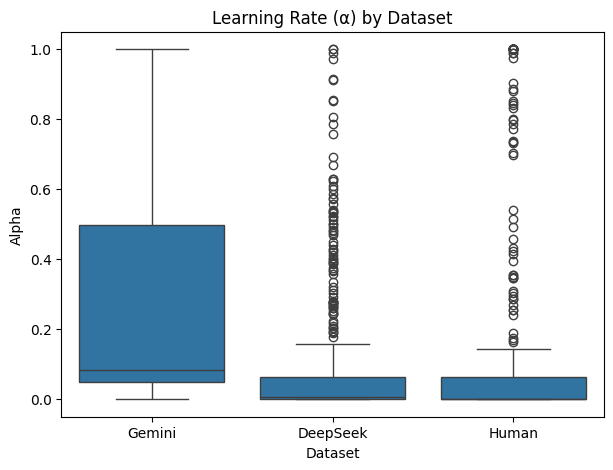

In [10]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="dataset", y="alpha")
plt.title("Learning Rate (α) by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Alpha")
plt.show()

- Gemini shows higher and more variable learning rates (alpha)  
- DeepSeek and Human are concentrated near low alpha values  
- Median alpha is similar across datasets (low), indicating generally slow learning  
- Gemini has a much wider spread → more inconsistent learning behaviour  
- DeepSeek and Human distributions are more tightly clustered → more stable learning patterns  
- Overall: Gemini exhibits greater variability, while DeepSeek aligns more closely with human learning behaviour

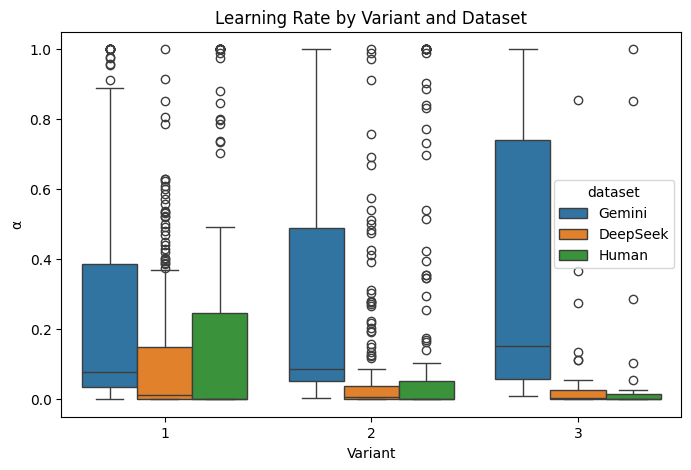

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="variant", y="alpha", hue="dataset")
plt.title("Learning Rate by Variant and Dataset")
plt.xlabel("Variant")
plt.ylabel("α")
plt.show()

- Gemini shows consistently higher and more variable alpha across all variants  
- DeepSeek and Human remain concentrated at low alpha values in all variants  
- Variant 3 increases variability for Gemini (wider spread, higher median)  
- DeepSeek and Human show little change across variants → stable behaviour  
- Human alpha is slightly higher than DeepSeek in Variant 1 but converges in later variants  
- Overall: variant manipulation affects Gemini more, while DeepSeek and Human remain relatively consistent

## Choice Consistency Across Models

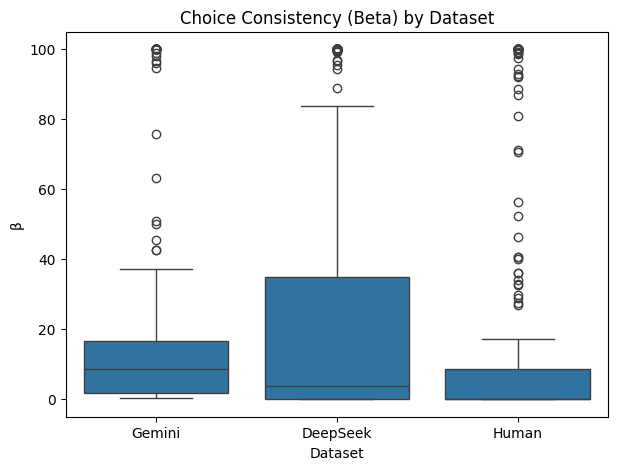

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="dataset", y="beta")
plt.title("Choice Consistency (Beta) by Dataset")
plt.xlabel("Dataset")
plt.ylabel("β")
plt.show()

- Gemini has higher median beta → more consistent (deterministic) choices  
- DeepSeek shows the widest spread → highly variable consistency  
- Human data is mostly low beta → more stochastic (less consistent) choices  
- All datasets contain high-beta outliers → occasional very deterministic behaviour  
- DeepSeek variability suggests unstable decision patterns  
- Overall: Gemini is most consistent, Human least, DeepSeek most variable

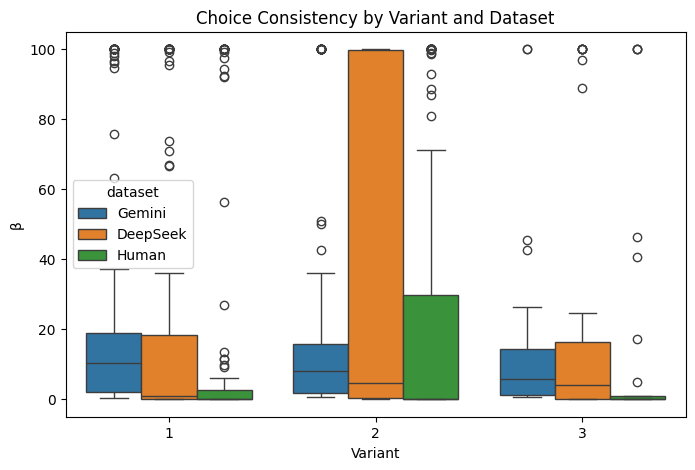

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="variant", y="beta", hue="dataset")
plt.title("Choice Consistency by Variant and Dataset")
plt.xlabel("Variant")
plt.ylabel("β")
plt.show()

- Gemini shows consistently higher beta across all variants → more deterministic choices  
- DeepSeek displays large variability, especially in Variant 2 → unstable decision consistency  
- Human data remains low beta across all variants → more stochastic behaviour  
- Variant 2 increases variability for DeepSeek and Human more than other variants  
- Variant 3 reduces spread across all datasets → more consistent behaviour overall  
- Overall: Gemini is most stable, Human least consistent, DeepSeek most sensitive to task variation

### Percentage of Runs at Beta Ceiling

In [14]:
beta_max = 100
tol = 1e-3

ceiling_summary = (
    df.assign(beta_ceiling=df["beta"] >= beta_max - tol)
      .groupby("dataset")["beta_ceiling"]
      .mean()
      .reset_index()
)

ceiling_summary["beta_ceiling"] = ceiling_summary["beta_ceiling"] * 100
print(ceiling_summary)

    dataset  beta_ceiling
0  DeepSeek     20.222222
1    Gemini     10.666667
2     Human     15.121951


## Alpha vs Beta Across Models

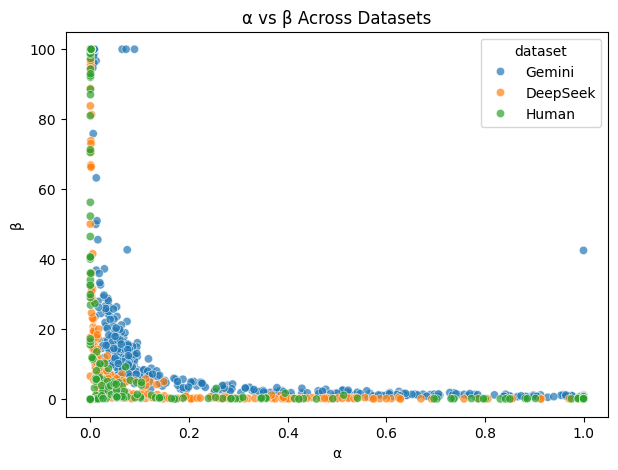

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="alpha", y="beta", hue="dataset", alpha=0.7)
plt.title("α vs β Across Datasets")
plt.xlabel("α")
plt.ylabel("β")
plt.show()

- Clear inverse relationship between alpha and beta across all datasets  
- Low alpha is associated with very high beta (more deterministic behaviour)  
- As alpha increases, beta rapidly decreases → more stochastic choices  
- Many points at very low alpha with high beta → slow learning but strong consistency  
- Gemini shows wider spread, especially higher beta values  
- DeepSeek and Human follow similar patterns with tighter distributions  
- Presence of high-beta values near alpha ≈ 0 suggests possible ceiling effects  
- Overall: learning rate and choice consistency are strongly coupled across datasets

## Model Fit Across Models

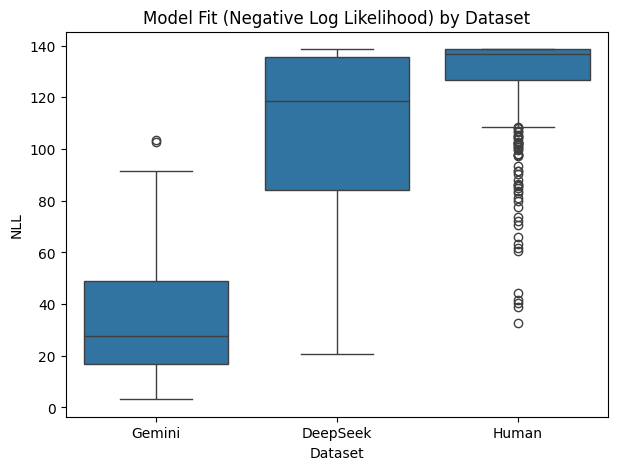

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="dataset", y="nll")
plt.title("Model Fit (Negative Log Likelihood) by Dataset")
plt.xlabel("Dataset")
plt.ylabel("NLL")
plt.show()

- Gemini has the lowest NLL → best model fit to behaviour  
- DeepSeek shows higher NLL → poorer fit and more variability  
- Human data has the highest NLL → hardest to model with RW  
- Wider spread in DeepSeek and Human → more complex/variable behaviour  
- Gemini’s tighter distribution suggests more predictable patterns  
- Overall: RW model fits LLM behaviour better than human behaviour

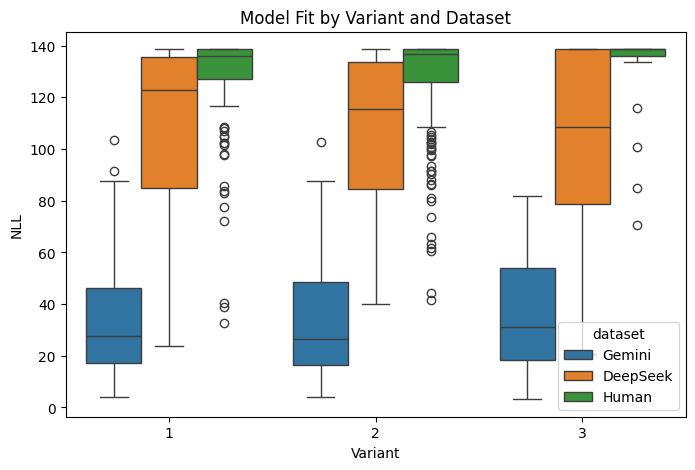

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="variant", y="nll", hue="dataset")
plt.title("Model Fit by Variant and Dataset")
plt.xlabel("Variant")
plt.ylabel("NLL")
plt.show()

* Gemini consistently has the lowest NLL across all variants → best model fit
* DeepSeek shows higher and more variable NLL → less consistent fit
* Human data has the highest NLL → hardest to model with RW

* Variant effects:
   * Gemini remains stable across variants
   * DeepSeek shows noticeable variability across variants
   * Human fit remains consistently high (poor fit) across variants

* Spread:
   * DeepSeek has the widest spread → more behavioural variability
   * Gemini is tighter → more predictable behaviour

* Overall:
   * RW model fits LLM behaviour (especially Gemini) better than human behaviour, regardless of variant